In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

SCRIPTS = Path('..') / 'ejemplos_codigo'
print('[OK] Entorno B09 listo')

[OK] Entorno B09 listo


In [2]:
# Crear directorio de exportacion de imagenes
import os
os.makedirs('images', exist_ok=True)
print('[OK] Directorio images/ listo')

[OK] Directorio images/ listo


# RAG y Gestión de la Base de Conocimiento

RAG (Retrieval Augmented Generation) es la arquitectura que permite a un LLM  
responder con información específica, actualizada y verificable  
en lugar de depender exclusivamente de su conocimiento interno.

**Para la empresa**: RAG transforma un modelo genérico en un asistente que conoce  
los productos, la documentación técnica, los procesos internos y el histórico de cada cliente.

**Actividad de calentamiento - Busca en tu memoria vs busca en el documento:**  
Se hace una pregunta técnica sobre la empresa.  
Los participantes responden primero de memoria,  
y despues se les da acceso al documento fuente.  
La diferencia entre ambas respuestas ilustra exactamente por que RAG es necesario.

```
Sin RAG:  LLM conocimiento general  ->  respuesta aproximada (puede alucinar)
Con RAG:  documentos reales  -->  LLM como sintetizador  ->  respuesta verificable
```

> **Antes de seguir:** ¿dónde está el conocimiento más valioso de tu empresa: en la cabeza de las personas, en documentos escritos, o en los datos históricos? ¿Cómo cambiaría eso el sistema que necesitarías?

<details>
<summary>Orientación para el instructor (desplegar tras la reflexión)</summary>

**Una respuesta madura menciona al menos uno de estos elementos:**
- Si el conocimiento está en personas: es difícil de indexar, se pierde con la rotación, y requiere entrevistas o ejemplos para capturarlo
- Si está en documentos: RAG es la arquitectura natural, pero la calidad del sistema depende de la calidad y actualización de la documentación
- Si está en datos históricos: modelos de ML o análisis estadístico son más apropiados que un LLM
- La combinación más frecuente: las tres fuentes a la vez, con RAG sobre documentos + ML sobre datos + acceso a expertos para casos sin precedente

**Si nadie responde, preguntar:**
"Cuando un consultor de la empresa necesita responder una pregunta técnica sobre la empresa que no recuerda, ¿a quién pregunta o qué busca? ¿Qué pasaría si esa persona no estuviera disponible?"

**Señal de comprensión:**
El alumno conecta el tipo de conocimiento con la arquitectura adecuada. Si puede decir "en mi empresa el conocimiento está principalmente en X, por eso necesitaría Y", ha aplicado el marco conceptual del bloque antes de ver el código.

</details>

## 9.1 Embeddings: Representación Vectorial del Significado

Un embedding es una representación numérica de un texto  
en un espacio vectorial de alta dimensión (768 a 3072 dims).

**Propiedad fundamental**: textos con significado similar producen vectores cercanos.

```
'El stock del producto esta agotado'     --> [0.23, -0.41, 0.87, ..., 0.12]  (768 dims)
'No quedan unidades disponibles'         --> [0.21, -0.39, 0.85, ..., 0.14]  (CERCANO)
'La factura tiene un error de calculo'   --> [-0.55, 0.72, -0.11, ..., 0.63] (LEJANO)
```

La distancia se mide con **similaridad coseno**: el coseno del ángulo entre vectores.  
- 1.0 = idéntico significado  
- 0.0 = sin relación  
- -1.0 = significados opuestos

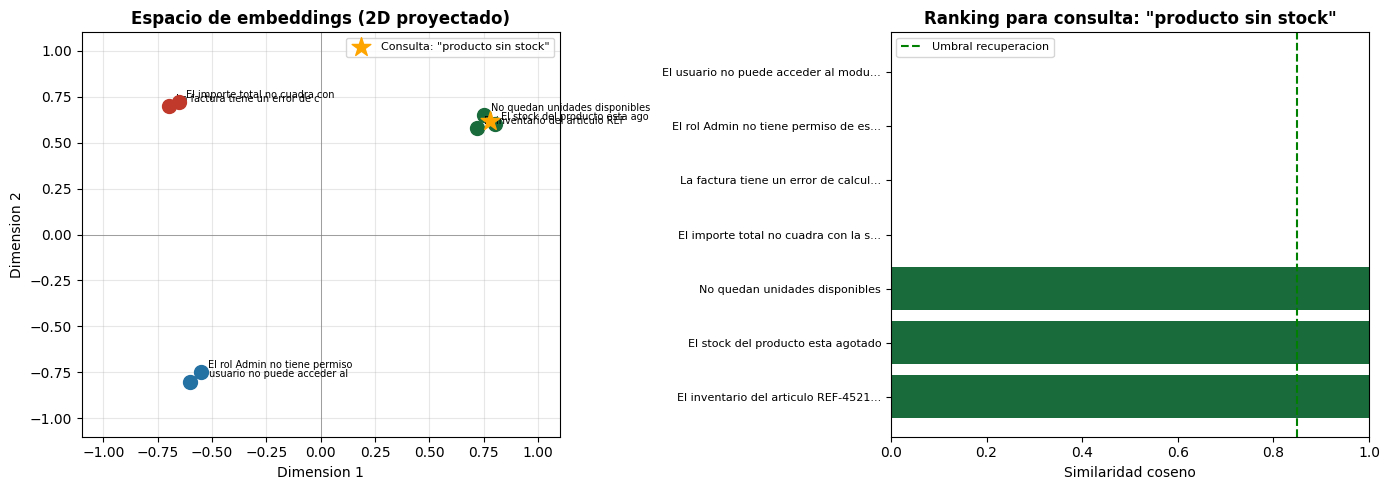


Top-3 documentos mas relevantes:
  1.000  "El inventario del articulo REF-4521 es 0"
  1.000  "El stock del producto esta agotado"
  0.999  "No quedan unidades disponibles"

Documento menos relevante:
  -0.967  "El usuario no puede acceder al modulo"


In [3]:
# Similaridad coseno: implementacion y visualizacion

def cosine_similarity(vec_a: np.ndarray, vec_b: np.ndarray) -> float:
    """Calcula la similaridad coseno entre dos vectores."""
    dot = np.dot(vec_a, vec_b)
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return dot / (norm_a * norm_b)


# Embeddings simulados en 2D para visualizacion (en produccion son 768+ dims)
# Cada frase tiene un embedding 2D aproximado por su semantica
docs_2d = {
    # Cluster de 'stock / inventario'
    'El stock del producto esta agotado':       np.array([0.8,  0.6]),
    'No quedan unidades disponibles':            np.array([0.75, 0.65]),
    'El inventario del articulo REF-4521 es 0': np.array([0.72, 0.58]),
    # Cluster de 'facturas / contabilidad'
    'La factura tiene un error de calculo':      np.array([-0.7, 0.7]),
    'El importe total no cuadra con la suma':    np.array([-0.65, 0.72]),
    # Cluster de 'usuarios / permisos'
    'El usuario no puede acceder al modulo':     np.array([-0.6, -0.8]),
    'El rol Admin no tiene permiso de escritura':np.array([-0.55, -0.75]),
}

consulta_texto = 'producto sin stock'
consulta_vec = np.array([0.78, 0.62])  # semanticamente cercana al cluster de stock

# Calcular similitudes
similitudes = [
    (texto, cosine_similarity(consulta_vec, vec))
    for texto, vec in docs_2d.items()
]
similitudes.sort(key=lambda x: x[1], reverse=True)

# Visualizacion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Mapa vectorial
colores_cluster = {
    0: '#1a6b3c', 1: '#1a6b3c', 2: '#1a6b3c',   # stock
    3: '#c0392b', 4: '#c0392b',                   # facturas
    5: '#2471a3', 6: '#2471a3',                   # usuarios
}
for i, (texto, vec) in enumerate(docs_2d.items()):
    ax1.scatter(*vec, color=colores_cluster[i], s=100, zorder=3)
    ax1.annotate(texto[:30], vec, textcoords='offset points', xytext=(5, 3), fontsize=7)
ax1.scatter(*consulta_vec, color='orange', s=200, marker='*', zorder=4, label=f'Consulta: "{consulta_texto}"')
ax1.set_title('Espacio de embeddings (2D proyectado)', fontweight='bold')
ax1.set_xlabel('Dimension 1'); ax1.set_ylabel('Dimension 2')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-1.1, 1.1); ax1.set_ylim(-1.1, 1.1)
ax1.axhline(0, color='gray', linewidth=0.5); ax1.axvline(0, color='gray', linewidth=0.5)

# Ranking de similitudes
textos_cortos = [t[:35] + '...' if len(t) > 35 else t for t, _ in similitudes]
sims = [s for _, s in similitudes]
colores_bar = ['#1a6b3c' if s > 0.9 else '#e8a020' if s > 0.5 else '#c0392b' for s in sims]
ax2.barh(range(len(sims)), sims, color=colores_bar)
ax2.set_yticks(range(len(sims)))
ax2.set_yticklabels(textos_cortos, fontsize=8)
ax2.set_xlabel('Similaridad coseno')
ax2.set_title(f'Ranking para consulta: "{consulta_texto}"', fontweight='bold')
ax2.axvline(0.85, color='green', linestyle='--', label='Umbral recuperacion')
ax2.legend(fontsize=8)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('images/B09_fig01.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print('\nTop-3 documentos mas relevantes:')
for texto, sim in similitudes[:3]:
    print(f'  {sim:.3f}  "{texto}"')
print('\nDocumento menos relevante:')
print(f'  {similitudes[-1][1]:.3f}  "{similitudes[-1][0]}"')

## 9.2 Arquitectura RAG: El Flujo Completo

```
 BASE DE CONOCIMIENTO (documentos indexados)
           |
           v
PREGUNTA --> [1. EMBEDDING] --> [2. BUSQUEDA] --> Fragmentos relevantes
    |                                                      |
    +-------------------> [3. GENERACION CON CONTEXTO] <--+
                                    |
                                    v
                         RESPUESTA (con citas y fuentes)
```

1. **Embedding de la consulta**: la pregunta se convierte en un vector.
2. **Búsqueda**: los K fragmentos mas similares al vector de la consulta.
3. **Generación aumentada**: los fragmentos se insertan en el prompt como contexto.

**Chunking**: antes de indexar, los documentos se dividen en fragmentos (chunks).  
Rango típico: 200-1000 tokens por chunk, con 10-20% de solapamiento.

In [4]:
# Implementacion de chunking y pipeline RAG simplificado

def fixed_size_chunks(texto: str, chunk_size: int = 200, overlap: int = 30) -> list:
    """Divide el texto en chunks de tamano fijo con solapamiento."""
    chunks = []
    start = 0
    while start < len(texto):
        end = start + chunk_size
        chunk = texto[start:end].strip()
        if chunk:
            chunks.append(chunk)
        start = end - overlap
    return chunks


# Documento de ejemplo: manual de inventarios de la empresa (fragmento)
DOCUMENTO_EJEMPLO = """
Manual de Inventarios la empresa v3.2 - Seccion 4.1: Punto de Pedido

El calculo del punto de pedido utiliza la formula: PP = DM * LT + SS, donde DM es
la demanda media diaria, LT es el lead time en dias, y SS es el stock de seguridad
calculado con un nivel de servicio del 95%.

Para configurar el punto de pedido en el sistema, navegar a Inventarios > Configuracion
> Parametros de reposicion. Seleccionar el articulo y activar el calculo automatico.

El sistema recalcula el punto de pedido cada noche a las 01:00 UTC basandose en el
consumo de los ultimos 90 dias. Si el articulo tiene menos de 30 dias de historico,
el sistema usa los parametros manuales hasta tener datos suficientes.

Seccion 4.2: Stock de Seguridad

El stock de seguridad protege contra variabilidad de la demanda y del lead time.
La formula es SS = Z * sigma_LT, donde Z es el factor del nivel de servicio y
sigma_LT es la desviacion estandar de la demanda durante el lead time.

Para un nivel de servicio del 95%, Z = 1.645. Para el 99%, Z = 2.326.
El nivel de servicio se configura por categoria de articulo en Inventarios > Categorias.
"""

chunks = fixed_size_chunks(DOCUMENTO_EJEMPLO, chunk_size=300, overlap=50)
print(f'=== Chunking del documento ===')
print(f'Documento: {len(DOCUMENTO_EJEMPLO)} caracteres')
print(f'Chunks generados: {len(chunks)} (chunk_size=300, overlap=50)')
print()
for i, chunk in enumerate(chunks):
    print(f'--- Chunk {i+1} ({len(chunk)} chars) ---')
    print(chunk[:150] + ('...' if len(chunk) > 150 else ''))
    print()

=== Chunking del documento ===
Documento: 1116 caracteres
Chunks generados: 5 (chunk_size=300, overlap=50)

--- Chunk 1 (298 chars) ---
Manual de Inventarios la empresa v3.2 - Seccion 4.1: Punto de Pedido

El calculo del punto de pedido utiliza la formula: PP = DM * LT + SS, donde DM e...

--- Chunk 2 (300 chars) ---
un nivel de servicio del 95%.

Para configurar el punto de pedido en el sistema, navegar a Inventarios > Configuracion
> Parametros de reposicion. Sel...

--- Chunk 3 (300 chars) ---
noche a las 01:00 UTC basandose en el
consumo de los ultimos 90 dias. Si el articulo tiene menos de 30 dias de historico,
el sistema usa los parametro...

--- Chunk 4 (300 chars) ---
otege contra variabilidad de la demanda y del lead time.
La formula es SS = Z * sigma_LT, donde Z es el factor del nivel de servicio y
sigma_LT es la ...

--- Chunk 5 (115 chars) ---
5. Para el 99%, Z = 2.326.
El nivel de servicio se configura por categoria de articulo en Inventarios > Categorias.



In [5]:
# Vector store simplificado y pipeline RAG completo

import hashlib

class SimpleVectorStore:
    """Vector store en memoria para demostracion."""

    def __init__(self):
        self.documents = []  # [(vector, texto, metadata)]

    def _fake_embed(self, texto: str) -> np.ndarray:
        """
        Embedding simulado deterministico.
        En produccion: openai.Embedding.create() o similar.
        """
        # Basado en palabras clave para que la busqueda tenga sentido
        vec = np.zeros(8)
        kw_map = {
            'punto de pedido': [0, 1],
            'stock': [0, 2],
            'formula': [1, 2],
            'calculo': [1, 3],
            'seguridad': [2, 3],
            'nivel de servicio': [2, 4],
            'lead time': [3, 4],
            'sistema': [4, 5],
            'configuracion': [5, 6],
        }
        t = texto.lower()
        for kw, dims in kw_map.items():
            if kw in t:
                for d in dims:
                    vec[d] += 1.0
        norm = np.linalg.norm(vec)
        return vec / norm if norm > 0 else vec

    def insert(self, texto: str, metadata: dict) -> None:
        vec = self._fake_embed(texto)
        self.documents.append((vec, texto, metadata))

    def similarity_search(self, consulta: str, top_k: int = 3) -> list:
        query_vec = self._fake_embed(consulta)
        resultados = [
            (cosine_similarity(query_vec, doc_vec), texto, meta)
            for doc_vec, texto, meta in self.documents
        ]
        resultados.sort(key=lambda x: x[0], reverse=True)
        return resultados[:top_k]


def rag_pipeline(pregunta: str, vector_store: SimpleVectorStore, top_k: int = 3) -> dict:
    """Pipeline RAG simplificado (sin llamada real al LLM)."""
    # Paso 2: busqueda
    fragmentos = vector_store.similarity_search(pregunta, top_k=top_k)
    # Paso 3: construir prompt con contexto
    contexto = '\n\n'.join([
        f'[Fuente: {meta["fuente"]}, seccion: {meta["seccion"]}]\n{texto}'
        for sim, texto, meta in fragmentos
    ])
    prompt = (
        'Responde la siguiente pregunta basandote EXCLUSIVAMENTE en la informacion proporcionada.\n'
        'Si la informacion no es suficiente, indica que no tienes datos suficientes.\n'
        'Cita la fuente de cada afirmacion.\n\n'
        f'Contexto:\n{contexto}\n\n'
        f'Pregunta: {pregunta}\n\nRespuesta:'
    )
    return {
        'pregunta': pregunta,
        'fragmentos_recuperados': [(sim, meta) for sim, _, meta in fragmentos],
        'prompt': prompt,
    }


# Indexar el documento de ejemplo
vs = SimpleVectorStore()
for i, chunk in enumerate(chunks):
    vs.insert(chunk, metadata={
        'fuente': 'Manual Inventarios v3.2',
        'seccion': f'4.{i+1}',
        'chunk_index': i,
        'fecha_indexacion': datetime.now().isoformat(),
    })

print(f'Vector store indexado: {len(vs.documents)} chunks')

# Ejecutar consulta
resultado = rag_pipeline(
    'Como se calcula el punto de pedido y donde se configura en el sistema?',
    vs,
    top_k=2,
)

print(f'\nConsulta: "{resultado["pregunta"]}"')
print('\nFragmentos recuperados:')
for sim, meta in resultado['fragmentos_recuperados']:
    print(f'  Sim={sim:.3f} | {meta["fuente"]} | seccion {meta["seccion"]}')
print('\nPrompt generado (primeras 300 chars):')
print(resultado['prompt'][:300] + '...')

Vector store indexado: 5 chunks

Consulta: "Como se calcula el punto de pedido y donde se configura en el sistema?"

Fragmentos recuperados:
  Sim=0.875 | Manual Inventarios v3.2 | seccion 4.2
  Sim=0.540 | Manual Inventarios v3.2 | seccion 4.1

Prompt generado (primeras 300 chars):
Responde la siguiente pregunta basandote EXCLUSIVAMENTE en la informacion proporcionada.
Si la informacion no es suficiente, indica que no tienes datos suficientes.
Cita la fuente de cada afirmacion.

Contexto:
[Fuente: Manual Inventarios v3.2, seccion: 4.2]
un nivel de servicio del 95%.

Para confi...


## 9.3 Vector Stores: Opciones para la empresa

| Vector Store | Tipo | Caso de Uso | Notas |
|---|---|---|---|
| **ChromaDB** | Open source, local | Prototipos y desarrollo | Ligero, fácil de integrar |
| **Pinecone** | Cloud gestionado | Producción | Escalable, sin infraestructura propia |
| **Weaviate** | Open source, self-hosted | Producción con control total | Búsqueda híbrida, GraphQL API |
| **Qdrant** | Open source, self-hosted | Producción alto rendimiento | Filtrado por metadatos, escrito en Rust |
| **pgvector** | Extension PostgreSQL | Integración stack existente | Si ya usas PostgreSQL, añadir búsqueda vectorial |

**Recomendación para la empresa:**  
- Empezar con ChromaDB para prototipos.  
- Migrar a Qdrant o pgvector para producción,  
  segun si el equipo prefiere un servicio dedicado  
  o integrar en su PostgreSQL existente.

## 9.4 Búsqueda Híbrida

```
Consulta: "Error en módulo REF-4521 versión 3.2"

Búsqueda semántica:  encuentra docs sobre errores en módulos (concepto)
Búsqueda keyword:    encuentra docs con 'REF-4521' y '3.2' literales
Fusion (RRF):        combina ambos rankings -> mejores resultados
```

**Reranking**: despues de recuperar 20-50 candidatos con búsqueda vectorial,  
un cross-encoder reordena los top-3/5 con mayor precisión.

## 9.5 Taxonomía de la Base de Conocimiento

**Un RAG es tan bueno como su información.**  
Indexar documentos desactualizados o de baja calidad produce respuestas incorrectas  
con apariencia de autoridad - peor que no tener RAG.

**Estructura recomendada para la empresa:**
```
Base de Conocimiento
|-- Documentación Técnica
|   |-- Arquitectura del Sistema (versionada)
|   |-- API Reference (auto-generada desde codigo)
|   |-- Guias de Configuración (por modulo)
|   +-- Changelog y Release Notes
|-- Documentación Funcional
|   |-- Manuales de Usuario (por modulo)
|   |-- FAQs de Soporte (actualizadas periodicamente)
|   +-- Casos de Uso y Best Practices
|-- Conocimiento Comercial
|   |-- Fichas de Producto
|   |-- Respuestas a RFPs Anteriores
+-- Conocimiento Interno
    |-- Procesos y Procedimientos
    |-- Decisiones de Arquitectura (ADRs)
    +-- Post-mortems de Incidencias
```

**Control de calidad antes de indexar:**
- Es la versión mas reciente?
- Es información verificada o un borrador?
- Contiene datos confidenciales que no deben exponerse?
- El formato permite un chunking de calidad?

---
## 7. Ejercicio de Decisión: ¿usarias IA aquí?

### Caso: el RAG que funciona solo el 60% del tiempo

la empresa implementa un asistente RAG para que los consultores puedan preguntar
sobre la documentacion técnica de la empresa. Han indexado 800 páginas de manuales.
En las pruebas, el sistema da respuestas correctas el 60% del tiempo.

El responsable técnico dice que "con mas datos mejorara solo".

---

**Pregunta 1 - Las causas del 60%**
¿Por que podria el sistema tener solo 60% de precisión si la respuesta esta en los documentos?
Lista al menos 3 causas técnicas posibles que no tienen que ver con "faltan mas datos".

**Pregunta 2 - "Con mas datos mejorara"**
¿Es correcta esa afirmacion en el contexto de un RAG? ¿Cuando si y cuando no?

**Pregunta 3 - Diagnóstico del problema**
¿Como distinguirias si el problema esta en el retrieval (recuperación de fragmentos)
o en la generación (el LLM no usa bien lo que recupera)?

**Pregunta 4 - Las 3 primeras acciones**
Lista 3 acciones concretas que tomarias para mejorar del 60% al 80%
ANTES de añadir mas documentos.

---
*Escribe tus respuestas en la celda siguiente.*

### Mis respuestas

**Pregunta 1 - Las causas del 60%:**

*(escribe aquí)*

**Pregunta 2 - "Con mas datos mejorara":**

*(escribe aquí)*

**Pregunta 3 - Diagnóstico del problema:**

*(escribe aquí)*

**Pregunta 4 - Las 3 primeras acciones:**

*(escribe aquí)*

---

<!--
CRITERIOS DE Evaluación (para el instructor)

Pregunta 1 - Las causas del 60%:
Al menos 3 causas técnicas validas (que no sean "faltan datos"):
 - Chunking inadecuado: los fragmentos cortan el contexto justo en el punto relevante
 - Embeddings poco específicos para el dominio técnico de la empresa
 - Consultas mal formuladas por los usuarios que no coinciden con el vocabulario de los documentos
 - El LLM generador ignora los fragmentos recuperados y responde con conocimiento previo
 - Documentacion estructurada de forma que dificulta la recuperación (tablas, listas anidadas)
 - Índices sin actualización despues de las últimas versiones de la documentacion
Insuficiente: solo mencionar "el modelo no es suficientemente bueno".

Pregunta 2 - "Con mas datos mejorara":
Respuesta correcta: en un RAG, "mas datos" no mejora automaticamente la precisión.
Si el problema es el retrieval (recuperación), mas documentos pueden empeorar la precisión
al introducir mas ruido en los resultados.
Si el problema es la generación, el LLM base no mejora con mas documentos indexados.
Cuando si podria ayudar: si el 40% de fallos es por preguntas sobre temas no cubiertos.
Insuficiente: "si, siempre mas datos es mejor".

Pregunta 3 - Diagnóstico retrieval vs generación:
Método correcto: tomar una muestra de casos fallidos y hacer dos preguntas:
  1. El fragmento correcto aparece en el top-5 del retriever? (problema de retrieval si no)
  2. Si el fragmento esta, el LLM lo usa correctamente en la respuesta? (problema de generación si no)
Herramientas validas: logging de los fragmentos recuperados por consulta, evaluación manual.
Insuficiente: "probaria distintos modelos" sin un proceso de diagnóstico.

Pregunta 4 - Las 3 primeras acciones (antes de añadir documentos):
Acciones validas:
 - Revisar y optimizar la estrategia de chunking (tamaño, solapamiento)
 - Limpiar y normalizar el texto de los documentos (encabezados, números de página, ruido)
 - Mejorar las consultas de los usuarios con un paso de reformulacion (query rewriting)
 - Evaluar si el embedding model es adecuado para terminologia técnica del dominio
 - Añadir metadatos a los chunks para mejorar el filtrado
Incorrecto: "reindexar los documentos" sin cambiar nada del pipeline.
-->


## Resumen del Bloque 9

```
RAG = Embedding + Vector Store + Generación con Grounding
```

| Decisión | Opción | Cuando |
|---|---|---|
| Chunking | Tamaño fijo | Texto no estructurado |
| Chunking | Por estructura | Documentación técnica bien organizada |
| Búsqueda | Solo semántica | Consultas conceptuales |
| Búsqueda | Híbrida | Mezcla de conceptos e identificadores exactos |
| Vector Store | ChromaDB | Prototipo |
| Vector Store | pgvector / Qdrant | Producción la empresa |

**Grounding**: el modelo solo puede responder con información de los fragmentos.  
Si no esta en el contexto, debe decir 'no tengo información suficiente'.  
Esa limitacion deliberada es la que hace RAG confiable.

**Siguiente bloque**: IA para el Desarrollo de Software - 
como un agente autónomo transforma el flujo de trabajo del equipo .NET de la empresa.